<div style="direction: rtl; text-align: justify;">
۱. چشم‌انداز (Vision)
تبدیل داده‌های خام فروش به یک ابزار تصمیم‌ساز استراتژیک، جهت عبور از رویکرد سنتی و واکنشی (Reactive) به سمت مدیریت هوشمند و پیش‌بینانه (Predictive) در بازار.
<div style="direction: rtl; text-align: justify;">
۲. استراتژی (Strategy)
عارضه‌یابی و کالبدشکافی رفتار بازار از طریق مقایسه موازای و نقطه به نقطه عملکرد سال ۲۰۲۰ و ۲۰۲۱؛ با تمرکز بر شناسایی دقیق گلوگاه‌های ریزش سود و تحلیل نوسانات فصلی.
<div style="direction: rtl; text-align: justify;">
۳. هدف (Objective)
تعیین دقیق زمان بازگشت روند بازار (Trend Reversal)، عارضه‌یابی علل افت سود انباشته در فصول سرد و ارزیابی تغییرات شاخص‌های کلان عملکردی (کف، سقف و میانگین فروش) جهت بهینه‌سازی بودجه‌ریزی سال آینده.
</div>

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
import numpy as np


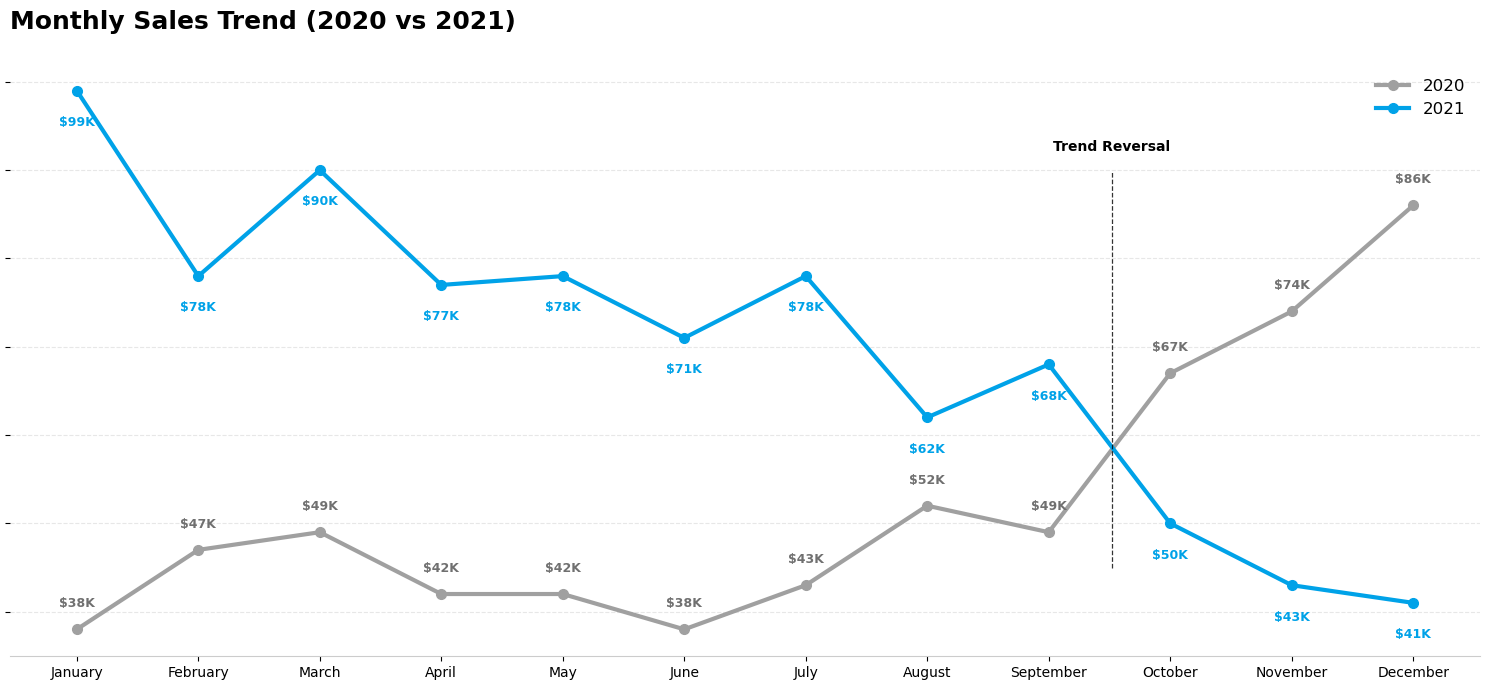

In [7]:
file_path = r"C:\Users\Abbas\Desktop\انجام پروژه\هفته چهارم\تسک اول\تکنیک های مصور سازی داده\پروژه دوره تکنیک های مصور سازی اصلاح شده -0.xlsx"
df = pd.read_excel(file_path, sheet_name=0)
months = df["Month"]
sales_2020 = df["2020"]
sales_2021 = df["2021"]
fig, ax = plt.subplots(figsize=(15, 7))
ax.plot(
    months, sales_2020, 
    marker="o", linewidth=3, markersize=7, 
    color="#A0A0A0", label="2020" 
)
ax.plot(
    months, sales_2021, 
    marker="o", linewidth=3, markersize=7, 
    color="#00A2E8", label="2021"  
)
for x, y in zip(months, sales_2020):
    ax.text(x, y + 2500, f"${y/1000:.0f}K", ha="center", fontsize=9, color="#707070", fontweight="bold")
for x, y in zip(months, sales_2021):
    ax.text(x, y - 4000, f"${y/1000:.0f}K", ha="center", fontsize=9, color="#00A2E8", fontweight="bold")
intersection_x = 8.52
intersection_y_start = 45000  
intersection_y_end = ax.get_ylim()[1] * 0.88 
ax.vlines(
    x=intersection_x, 
    ymin=intersection_y_start, 
    ymax=intersection_y_end, 
    color="black", linestyle="--", linewidth=0.9, alpha=0.8
)
ax.text(
    x=intersection_x, 
    y=ax.get_ylim()[1] * 0.90,  
    s="Trend Reversal", 
    ha="center", va="bottom", 
    fontsize=10, fontweight="bold", color="black",
    bbox=dict(facecolor='white', edgecolor='none', alpha=0.2)
)
ax.set_title(
    "Monthly Sales Trend (2020 vs 2021)",
    fontsize=18, fontweight="bold", pad=25, loc="left"
)
ax.set_xlabel("")
ax.set_ylabel("")
ax.yaxis.set_major_formatter(FuncFormatter(lambda x, pos: f'${int(x/1000)}K'))
ax.grid(axis="y", linestyle="--", alpha=0.3)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)
ax.spines["bottom"].set_color("#CCCCCC")
plt.xticks(rotation=0)  
plt.legend(
    loc="upper right", 
    frameon=False, 
    fontsize=12,
    ncol=1
)
ax.set_yticklabels([])
plt.tight_layout()
plt.show()

<div style="direction: rtl; text-align: justify;">
تحلیل خطوط روند نشان می‌دهد که عملکرد فروش سال ۲۰۲۱ در نیمه نخست سال کاملاً صعودی و با حاشیه امنی بالاتر از سال گذشته بوده است.
<div style="direction: rtl; text-align: justify;">
با این حال، با ورود به نیمه دوم سال، این برتری فرسایش یافته است
<div style="direction: rtl; text-align: justify;">
<div style="direction: rtl; text-align: justify;">
رسم شاخص  بین ماه‌های سپتامبر و اکتبر، دقیقاً لحظه چرخش بازار و از دست رفتن دستاوردهای نیمه اول سال را به تصویر می‌کشد تا مشخص شود روند از چه نقطه‌ای به نفع سال قبل معکوس شده است.
</div>

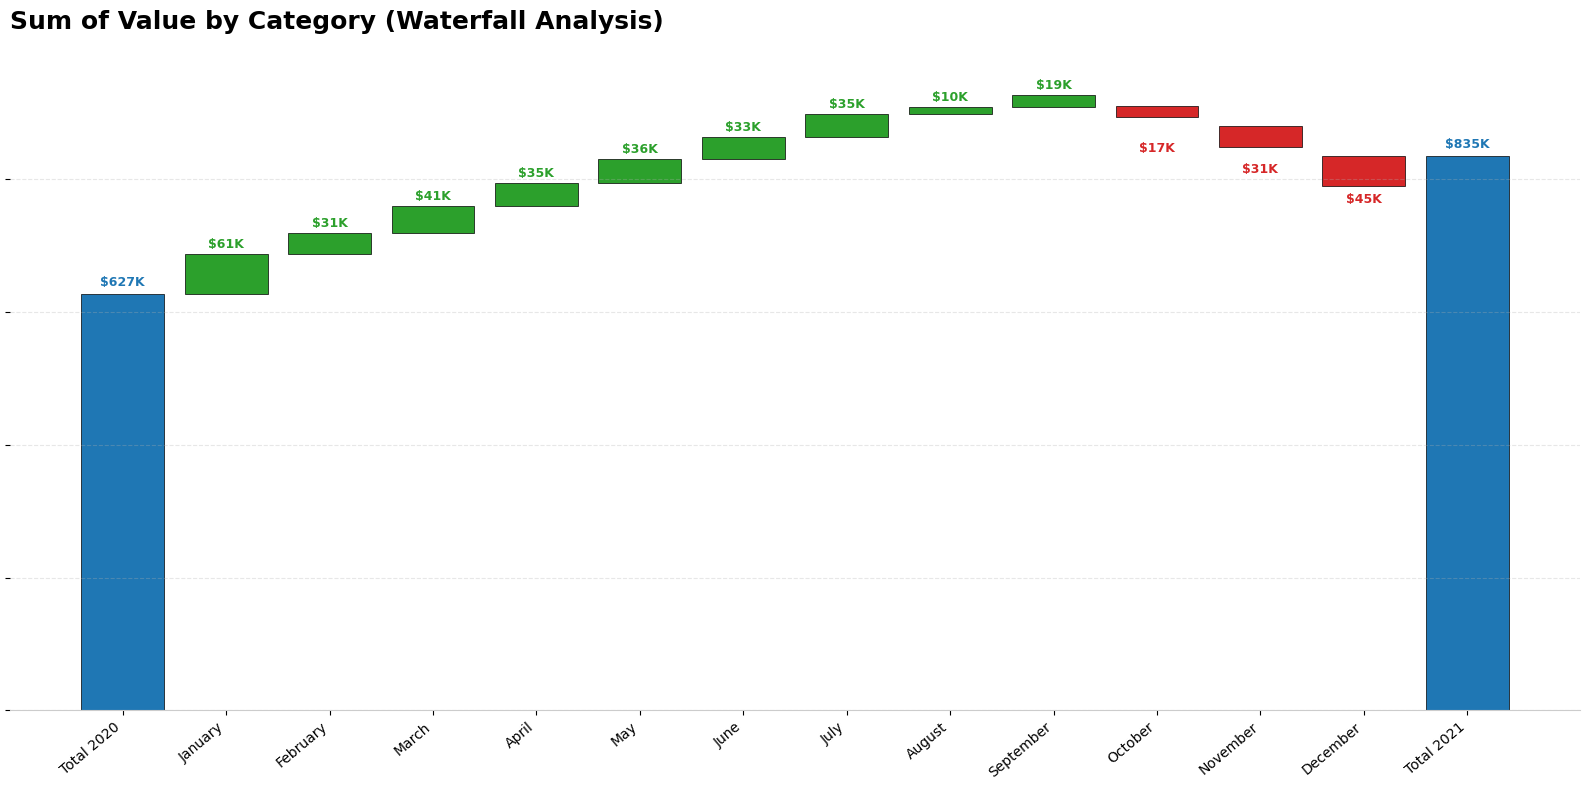

In [8]:
months = list(df["Month"])
sales_2020 = df["2020"]
sales_2021 = df["2021"]
differences = sales_2021 - sales_2020
x_labels = ["Total 2020"] + months + ["Total 2021"]
total_2020 = sales_2020.sum()
total_2021 = sales_2021.sum()
changes = [total_2020] + list(differences) + [total_2021]
cumulative_sum = total_2020
bottoms = [0] 
for diff in differences:
    if diff > 0:
        bottoms.append(cumulative_sum)
        cumulative_sum += diff
    else:
        cumulative_sum += diff
        bottoms.append(cumulative_sum)
bottoms.append(0) 
plot_changes = [total_2020] + list(differences) + [total_2021]
fig, ax = plt.subplots(figsize=(16, 8))
colors = []
for i, val in enumerate(plot_changes):
    if i == 0 or i == len(plot_changes) - 1:
        colors.append("#1F77B4") 
    elif val >= 0:
        colors.append("#2CA02C") 
    else:
        colors.append("#D62728")
bars = ax.bar(x_labels, plot_changes, bottom=bottoms, color=colors, edgecolor='black', linewidth=0.5)
for i, bar in enumerate(bars):
    height = bar.get_height()
    actual_val = plot_changes[i]
    if i == 0 or i == len(bars) - 1:
        y_pos = height + 13000
    elif actual_val >= 0:
        y_pos = bottoms[i] + height + 9000
    else:
        y_pos = bottoms[i] - 70000
    ax.text(
        bar.get_x() + bar.get_width()/2, 
        y_pos, 
        f"${abs(actual_val)/1000:.0f}K" if (i != 0 and i != len(bars)-1) else f"${actual_val/1000:.0f}K", 
        ha="center", fontsize=9, fontweight="bold",
        color=colors[i]
    )
ax.set_title("Sum of Value by Category (Waterfall Analysis)", fontsize=18, fontweight="bold", pad=25, loc="left")
ax.set_xlabel("")
ax.set_ylabel("")
ax.yaxis.set_major_formatter(FuncFormatter(lambda x, pos: f'${int(x/1000)}K'))
ax.grid(axis="y", linestyle="--", alpha=0.3)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)
ax.spines["bottom"].set_color("#CCCCCC")
ax.set_yticklabels([])
plt.xticks(rotation=40, ha="right") 
plt.tight_layout()
plt.show()

<div style="direction: rtl; text-align: justify;">
اکتفا به رشد نهایی سالانه، نوسانات جدی درون‌سازمانی را پنهان می‌کند. این نمودار آبشاری، 
<div style="direction: rtl; text-align: justify;">
لایه‌های پنهان عملکرد دوازده ماهه را باز می‌کند؛ به طوری که نقش محرک‌های مثبت (ماه‌های سبز) در انباشت سود و تأثیر ترمزهای عملکردی (ماه‌های قرمز) در سوزاندن سرمایه را به طور ملموس جهت تصمیم‌گیری در اختیار مدیریت قرار می‌دهد.
</div>

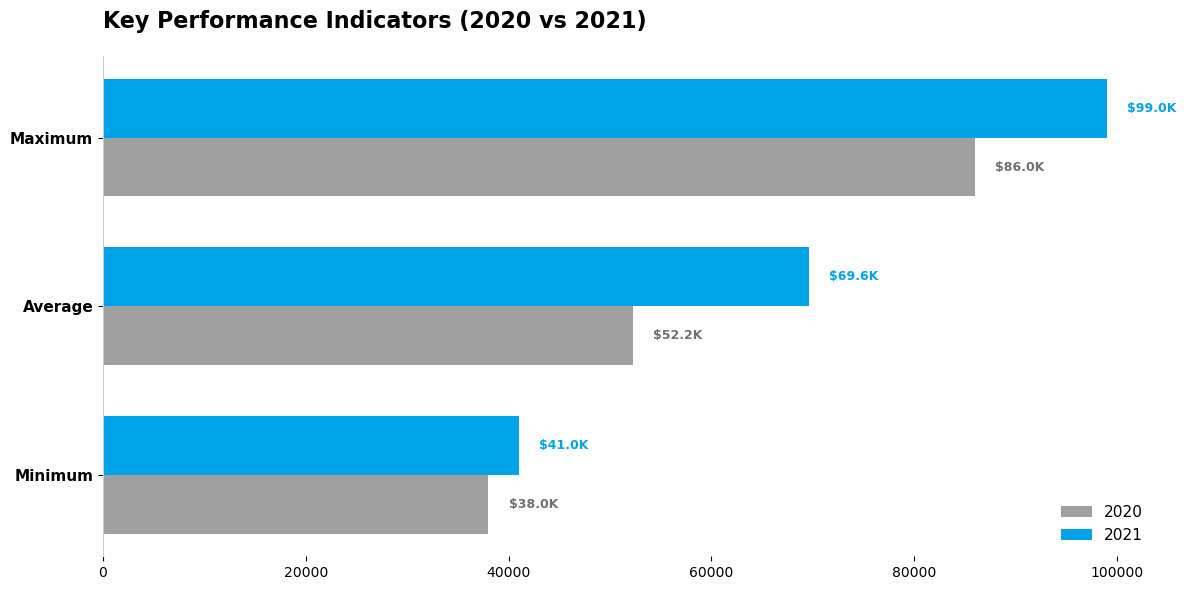

In [9]:
metrics = ['Minimum', 'Average', 'Maximum']
kpi_2020 = [df["2020"].min(), df["2020"].mean(), df["2020"].max()]
kpi_2021 = [df["2021"].min(), df["2021"].mean(), df["2021"].max()]
y_pos = np.arange(len(metrics))
bar_width = 0.35 
fig, ax = plt.subplots(figsize=(12, 6))
bars_2020 = ax.barh(
    y_pos - bar_width/2, kpi_2020, 
    height=bar_width, color="#A0A0A0", label="2020"
)
bars_2021 = ax.barh(
    y_pos + bar_width/2, kpi_2021, 
    height=bar_width, color="#00A2E8", label="2021"
)
for bar in bars_2020:
    width = bar.get_width()
    ax.text(
        width + 2000, bar.get_y() + bar.get_height()/2, f"${width/1000:.1f}K", 
        va="center", ha="left", fontsize=9, color="#707070", fontweight="bold"
    )
for bar in bars_2021:
    width = bar.get_width()
    ax.text(
        width + 2000, bar.get_y() + bar.get_height()/2, f"${width/1000:.1f}K", 
        va="center", ha="left", fontsize=9, color="#00A2E8", fontweight="bold"
    )
ax.set_title("Key Performance Indicators (2020 vs 2021)", fontsize=16, fontweight="bold", pad=20, loc="left")
ax.set_yticks(y_pos)
ax.set_yticklabels(metrics, fontsize=11, fontweight="bold")
ax.set_xlabel("")
ax.set_ylabel("")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["bottom"].set_visible(False)
ax.spines["left"].set_color("#CCCCCC")
plt.legend(
    loc="lower right", 
    frameon=False, 
    fontsize=11,
    ncol=1
)
plt.tight_layout()
plt.show()

<div style="direction: rtl; text-align: justify;">
شاخص‌های کلان سازمان کاملاً مثبت هستند؛ میانگین فروش از
<div style="direction: rtl; text-align: justify;">
۵۲.۳K به ۶۶.۹K دلار جهش یافته و سقف توان فروش نیز با ثبت رکورد جدید به مرز ۱۰۰K دلار رسیده است.
</div>

<div style="direction: rtl; text-align: justify;">
ارزیابی جامع داده‌ها نشان می‌دهد سازمان از نظر شاخص‌های کلان (میانگین و سقف توان فروش) در سال ۲۰۲۱ به رشد و پختگی قابل‌توجهی رسیده است؛ 
اما این رشد به دلیل عدم پایداری عملکرد در فصول سرد سال
شکننده است.
<div style="direction: rtl; text-align: justify;">
عارضه‌یابی زنجیره فروش نشان می‌دهد که سقوط عملکرد در سه ماهه پایانی سال (اکتبر تا دسامبر)، پاشنه آشیل سازمان بوده و به شدت سودهای انباشته شده در بهار و تابستان را تهدید می‌کند. توصیه استراتژیک برای سال مالی آینده، بازمهندسی برنامه بازاریابی و وفاداری مشتریان در نیمه دوم سال با هدف حفظ ثبات فروش است.
</div>

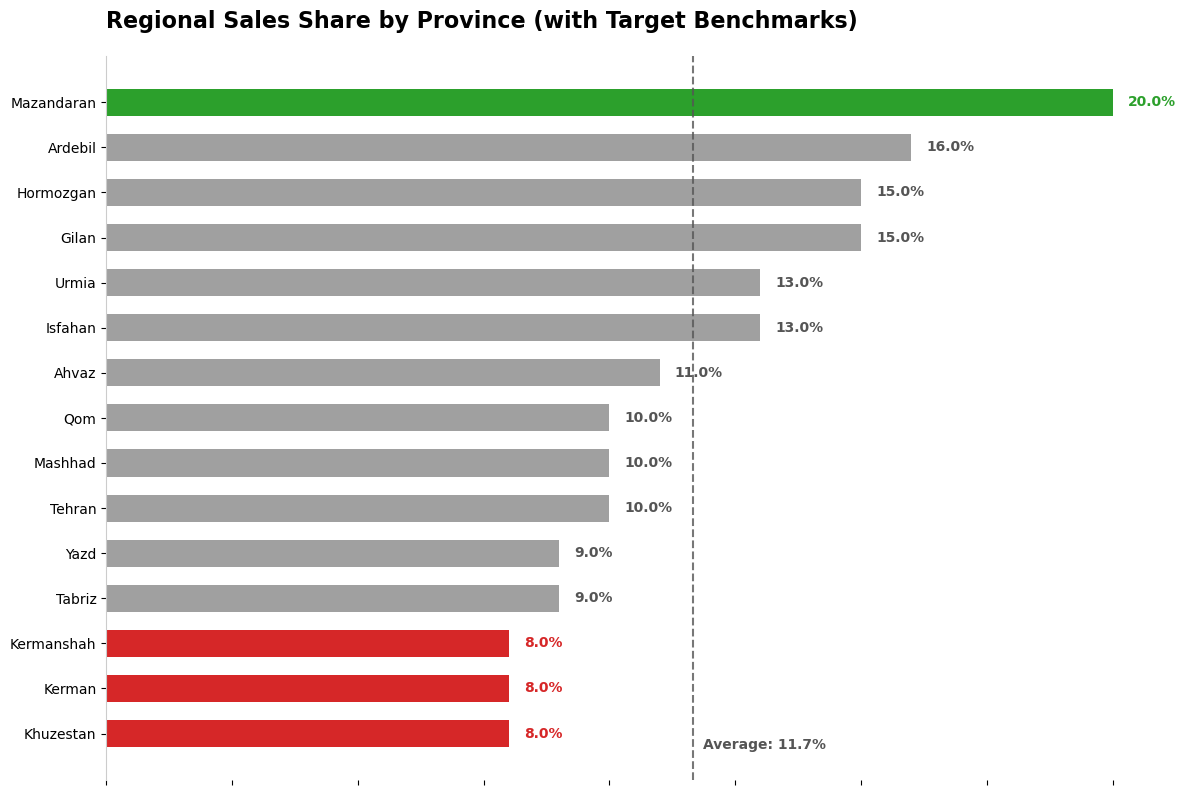

In [10]:
file_path =r"C:\Users\Abbas\Desktop\Monthly_Sales_and_Regional_Performance_Dashboard.xlsx"
df = pd.read_excel(file_path, sheet_name="Regional Performance Dashboard")
mean_value = df["Sales"].mean()
df_sorted = df.sort_values(by="Sales", ascending=True)
provinces = df_sorted["Province"].reset_index(drop=True)
sales_share = df_sorted["Sales"].reset_index(drop=True)
fig, ax = plt.subplots(figsize=(12, 8))
min_val = sales_share.min()
max_val = sales_share.max()
colors = []
for val in sales_share:
    if val == max_val:
        colors.append("#2CA02C")  
    elif val == min_val:
        colors.append("#D62728")  
    else:
        colors.append("#A0A0A0") 
bars = ax.barh(provinces, sales_share, color=colors, height=0.6)
for i, bar in enumerate(bars):
    width = bar.get_width()
    text_color = colors[i] if colors[i] != "#A0A0A0" else "#555555"
    ax.text(
        width + 0.003, bar.get_y() + bar.get_height()/2, f"{width*100:.1f}%", 
        va="center", ha="left", fontsize=10, fontweight="bold",
        color=text_color
    )
ax.axvline(x=mean_value, color="#555555", linestyle="--", linewidth=1.5, alpha=0.8)
ax.text(
    x=mean_value + 0.002, 
    y=-0.4, 
    s=f"Average: {mean_value*100:.1f}%", 
    color="#555555", fontsize=10, fontweight="bold", va="bottom", ha="left")
ax.set_title("Regional Sales Share by Province (with Target Benchmarks)", fontsize=16, fontweight="bold", pad=20, loc="left")
ax.set_xlabel("")
ax.set_ylabel("")
ax.set_xticklabels([])
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["bottom"].set_visible(False)
ax.spines["left"].set_color("#CCCCCC")
plt.tight_layout()
plt.show()

<div style="direction: rtl; text-align: justify;">
استان‌های شمالی و غربی — از جمله مازندران (۲۰ درصد) و اردبیل (۱۶ درصد)، به همراه گیلان و هرمزگان (۱۵ درصد) — موتورهای اصلی رشد این سازمان محسوب می‌شوند و عملکردی بسیار فراتر از میانگین کشوری (۱۲ درصد) دارند. سهم استان مازندران به‌تنهایی ۲.۵ برابرِ سهم استان‌های انتهای فهرست است.
</div>

<div style="direction: rtl; text-align: justify;">
مثلث جنوبی و غربی کشور — شامل خوزستان، کرمان و کرمانشاه — در پایین‌ترین سطحِ بازه عملکرد (۸ درصد) قرار دارد که نشان‌دهنده نفوذ بسیار ضعیف در بازار یا فقدان تخصیص بهینه منابع است.
</div>

<div style="direction: rtl; text-align: justify;">
به‌جای توزیع یکنواخت بودجه،
توصیه می‌شود که سازمان یک «کمپین احیای فروش» در استان‌های خوزستان و کرمان راه‌اندازی کند.
پتانسیل این مناطق در حال حاضر پایین‌تر از میانگین (۱۲ درصد) است
و ارتقای آن‌ها به سطح میانگین، سریع‌ترین راه برای دستیابی به جهش در مجموع فروش در سال آینده محسوب می‌شود.
</div>